# Support Vector Machine (SVM) Predictive Model

Imports

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, accuracy_score, 
    confusion_matrix, fbeta_score, precision_recall_curve, roc_curve,
    balanced_accuracy_score, average_precision_score
)
from sklearn.utils import resample
import matplotlib.pyplot as plt

Load tiers

In [2]:
tier1 = pd.read_csv("./tiers/tier1_basic.csv")["feature"].tolist()
tier2 = pd.read_csv("./tiers/tier2_clinical.csv")["feature"].tolist()
tier3 = pd.read_csv("./tiers/tier3_personalized.csv")["feature"].tolist()

tiers = {
    "Tier_1_Basic": tier1,
    "Tier_2_Clinical": tier2,
    "Tier_3_Personalized": tier3,
}

print(f'tier1: {len(tier1)} features')
print(f'tier2: {len(tier2)} features')
print(f'tier3: {len(tier3)} features')

tier1: 6 features
tier2: 10 features
tier3: 24 features


Load dataset, drop weight from X, but SAVE w

In [3]:
df = pd.read_pickle("./data/cleaned/NSDUH_2023_clean.pkl")

TARGET = "IRAMDEYR"
WEIGHT = "ANALWT2_C"

y = df[TARGET]
w = df[WEIGHT]
X = df.drop(columns=[TARGET, WEIGHT])

print(f'Total samples: {X.shape[0]}')

Total samples: 45133


Split train/test (consistent with feature selection)

In [4]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.2,
    stratify=y,
    random_state=42
)




Define metric helper

In [5]:
def evaluate_model(y_true, preds, probs):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

    specificity = tn / (tn + fp)
    sensitivity = recall_score(y_true, preds)  # same as recall
    ppv = precision_score(y_true, preds)
    npv = tn / (tn + fn)

    return {
        "Accuracy": accuracy_score(y_true, preds),
        # new (sensisty + specificity) / 2 -> it averages performance on both classes qually
        "Balanced_Accuracy": balanced_accuracy_score(y_true, preds),  # <-- NEW
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "ROC-AUC": roc_auc_score(y_true, probs),
        # new -> with an imblanced dataset, ROC-AUC can be misleading when model has a lot of false positives. More
        # Applicable for imbalanced datasets where positive class is rare.
        "PR_AUC": average_precision_score(y_true, probs),  # <-- NEW
        "F1": fbeta_score(y_true, preds, beta=1),
        "F2": fbeta_score(y_true, preds, beta=2),
    }

SVM Pipeline w/ Weighted Fitting + GridSearchCV

In [12]:
param_grid = {
    "clf__C": [0.01, 0.1, 1],              # Regularization (smaller = stronger)
    "clf__kernel": ["rbf"],          # Kernel type
    "clf__gamma": ["scale", "auto", 0.1], # RBF kernel coefficient
    "clf__class_weight": [None, "balanced"],   # Class imbalance handling
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
def build_model_random():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),  # CRITICAL for SVM
        ("clf", SVC(
            random_state=42,
            probability=True  # Required for predict_proba
        ))
    ])

    model = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=20, 
        scoring="recall",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    return model

# GridSearchCV 
def build_model_grid():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),  # CRITICAL for SVM
        ("clf", SVC(
            random_state=42,
            probability=True  # Required for predict_proba
        ))
    ])
    
    model = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="recall",
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    return model

Bootstrapped Confidence Intervals (ROC + PR)

In [7]:
def bootstrap_auc_ci(model, X, y, n_boot=1000):
    aucs = []

    for _ in range(n_boot):
        X_bs, y_bs = resample(X, y, replace=True)
        probs = model.predict_proba(X_bs)[:, 1]
        aucs.append(roc_auc_score(y_bs, probs))

    return np.percentile(aucs, [2.5, 97.5])


Baseline Model (Dummy Classifier)

In [ ]:
# dummy = DummyClassifier(strategy="most_frequent")
# dummy.fit(X_train, y_train)
# dummy_preds = dummy.predict(X_test)
# dummy_probs = np.zeros_like(dummy_preds)

# dummy_metrics = evaluate_model(y_test, dummy_preds, dummy_probs)

c:\Users\agila\Documents\STM\Predicting-Past-Year-Major-Depressive-Episode\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Train + Evaluate XGBoost on Each tier

In [13]:
results_random = []
curves_random = {}

for tier_name, features in tiers.items():

    print(f"\n----- Training SVM (RandomizedSearchCV) on {tier_name} ({len(features)} features) -----")
    
    start_time = time.time()

    Xtr = X_train[features]
    Xte = X_test[features]

    model = build_model_random()

    # Fit WITH survey weights
    model.fit(Xtr, y_train, clf__sample_weight=w_train)

    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1]

    metrics = evaluate_model(y_test, preds, probs)

    # Bootstrapped CI
    ci_low, ci_high = bootstrap_auc_ci(model, Xte, y_test)

    metrics["Tier"] = tier_name
    metrics["AUC_CI_Low"] = ci_low
    metrics["AUC_CI_High"] = ci_high
    metrics["Best_Params"] = model.best_params_

    results_random.append(metrics)
    
    # Store curve data for plotting later
    curves_random[tier_name] = {"y_true": y_test, "y_prob": probs}
    
    print(f"Best params: {model.best_params_}")
    print(f"Completed in {time.time() - start_time:.1f} seconds")


----- Training SVM (RandomizedSearchCV) on Tier_1_Basic (6 features) -----
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/Users/manav/miniconda3/envs/env-nsduh/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KeyboardInterrupt: 

Convert to DataFrame + Export

In [ ]:
results_random_df = pd.DataFrame(results_random)
results_random_df.to_csv("./results/svm_random_tier_performance.csv", index=False)

print(results_random_df)

NameError: name 'results_random' is not defined

In [ ]:

# Plot and save ROC Curve
plt.figure(figsize=(8, 6))
for tier_name, curve_data in curves_random.items():
    fpr, tpr, _ = roc_curve(curve_data["y_true"], curve_data["y_prob"])
    auc_score = results_random_df[results_random_df["Tier"] == tier_name]["ROC-AUC"].values[0]
    plt.plot(fpr, tpr, label=f"{tier_name} (AUC={auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (RandomizedSearchCV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("./results/figures/svm_random_roc_curve.png", dpi=300)
plt.show()

# Plot and save Precision-Recall Curve
plt.figure(figsize=(8, 6))
for tier_name, curve_data in curves_random.items():
    precision, recall, _ = precision_recall_curve(curve_data["y_true"], curve_data["y_prob"])
    pr_auc = results_random_df[results_random_df["Tier"] == tier_name]["PR_AUC"].values[0]
    plt.plot(recall, precision, label=f"{tier_name} (PR-AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM (RandomizedSearchCV)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("./results/figures/svm_random_pr_curve.png", dpi=300)
plt.show()

print("Curves saved to ./results/figures/")

NameError: name 'curves_random' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
results_grid = []
curves_grid = {}

for tier_name, features in tiers.items():

    print(f"\n----- Training SVM (GridSearchCV) on {tier_name} ({len(features)} features) -----")
    
    start_time = time.time()

    Xtr = X_train[features]
    Xte = X_test[features]

    model = build_model_grid()

    # Fit WITH survey weights
    model.fit(Xtr, y_train, clf__sample_weight=w_train)

    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1]

    metrics = evaluate_model(y_test, preds, probs)

    # Bootstrapped CI
    ci_low, ci_high = bootstrap_auc_ci(model, Xte, y_test)

    metrics["Tier"] = tier_name
    metrics["AUC_CI_Low"] = ci_low
    metrics["AUC_CI_High"] = ci_high
    metrics["Best_Params"] = model.best_params_

    results_grid.append(metrics)
    
    # Store curve data for plotting later
    curves_grid[tier_name] = {"y_true": y_test, "y_prob": probs}
    
    print(f"Best params: {model.best_params_}")
    print(f"Completed in {time.time() - start_time:.1f} seconds")


----- Training XGBoost (GridSearchCV) on Tier_1_Basic (6 features) -----
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 50, 'clf__scale_pos_weight': 9, 'clf__subsample': 0.8}
Completed in 19.4 seconds

----- Training XGBoost (GridSearchCV) on Tier_2_Clinical (10 features) -----
Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END clf__learning_rate=0.01, clf__max_depth=5, clf__n_estimators=50, clf__scale_pos_weight=9, clf__subsample=1.0; total time=   0.2s
[CV] END clf__learning_rate=0.05, clf__max_depth=7, clf__n_estimators=50, clf__scale_pos_weight=9, clf__subsample=0.8; total time=   0.1s
[CV] END clf__learning_rate=0.1, clf__max_depth=7, clf__n_estimators=100, clf__scale_pos_weight=1, clf__subsample=0.8; total time=   0.3s
[CV] END clf__learning_rate=0.05, clf__max_depth=5, clf__n_estimators=50, clf__scale_pos_weight=1, clf__subsample=1.0; total time=   0.1s
[CV] 

In [ ]:
results_grid_df = pd.DataFrame(results_grid)
results_grid_df.to_csv("./results/svm_grid_tier_performance.csv", index=False)

print(results_grid_df)

   Accuracy  Balanced_Accuracy  Sensitivity  Specificity       PPV       NPV  \
0  0.565526           0.644218     0.746384     0.542053  0.174600  0.942751   
1  0.872272           0.829246     0.773385     0.885106  0.466279  0.967839   
2  0.930209           0.933722     0.938284     0.929161  0.632229  0.991453   

    ROC-AUC    PR_AUC        F1        F2                 Tier  AUC_CI_Low  \
0  0.708552  0.250706  0.282998  0.450996         Tier_1_Basic    0.693359   
1  0.887454  0.652660  0.581792  0.683367      Tier_2_Clinical    0.875411   
2  0.985319  0.935596  0.755435  0.855460  Tier_3_Personalized    0.981958   

   AUC_CI_High                                        Best_Params  
0     0.724156  {'clf__learning_rate': 0.05, 'clf__max_depth':...  
1     0.898878  {'clf__learning_rate': 0.05, 'clf__max_depth':...  
2     0.988611  {'clf__learning_rate': 0.01, 'clf__max_depth':...  


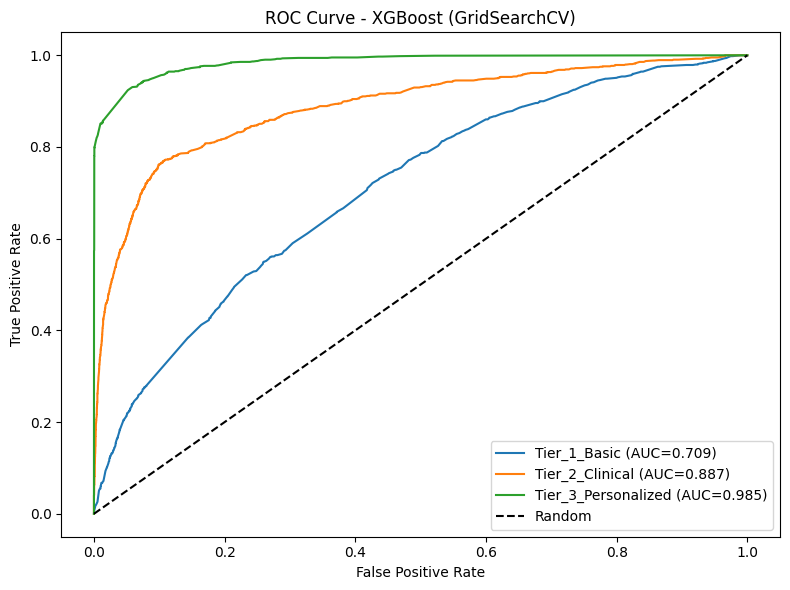

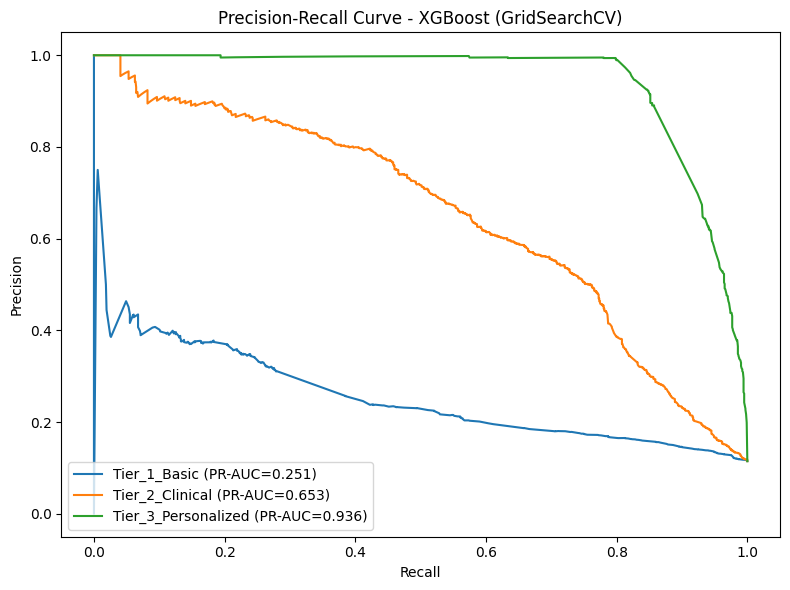

Curves saved to ./results/figures/


In [ ]:
plt.figure(figsize=(8, 6))
for tier_name, curve_data in curves_grid.items():
    fpr, tpr, _ = roc_curve(curve_data["y_true"], curve_data["y_prob"])
    auc_score = results_grid_df[results_grid_df["Tier"] == tier_name]["ROC-AUC"].values[0]
    plt.plot(fpr, tpr, label=f"{tier_name} (AUC={auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (GridSearchCV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("./results/figures/svm_grid_roc_curve.png", dpi=300)
plt.show()

# Plot and save Precision-Recall Curve
plt.figure(figsize=(8, 6))
for tier_name, curve_data in curves_grid.items():
    precision, recall, _ = precision_recall_curve(curve_data["y_true"], curve_data["y_prob"])
    pr_auc = results_grid_df[results_grid_df["Tier"] == tier_name]["PR_AUC"].values[0]
    plt.plot(recall, precision, label=f"{tier_name} (PR-AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM (GridSearchCV)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("./results/figures/svm_grid_pr_curve.png", dpi=300)
plt.show()

print("Curves saved to ./results/figures/")